In [65]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from langchain_groq import ChatGroq
from dotenv import load_dotenv

load_dotenv()

True

In [66]:
class QuadState(TypedDict) :
    a : int
    b : int
    c : int
    equation : str
    descriminant : float
    result : str

In [67]:
def show_equation(state :QuadState):
    equation = f"{state['a']}x**2{state['b']}x{state['c']}"
    return {
        "equation" : equation
    }

In [68]:
def calculate_descriminant(state : QuadState) :
    descriminant = (state['b']**2) - (4 * state['a'] * state['c'])
    return {
        'descriminant' : descriminant
    }

In [69]:
def real_roots(state:QuadState):
    root1 = (-state['b'] + state['descriminant']**0.5)/ 2 * state['a']
    root2 = (-state['b'] - state['descriminant']**0.5)/ 2 * state['a']
    result = f'the roots are {round(root1,2)} and {round(root2,2)}'
    return {
        'result' : result
    }

In [70]:
def repeated_roots(state:QuadState):
    root1 = (-state['b'] + state['descriminant']**0.5)/ 2 * state['a']
    result = f'only one root exists for this equation - {round(root1,2)}'
    return

In [71]:
def no_real_roots(state:QuadState):
    result = 'no roots exists for this equation'
    return {
        'result' : result
    }

In [72]:
### condition function

def check_condition(state : QuadState) -> Literal['real_roots', 'repeated_roots','no_real_roots']:
    if state['descriminant'] > 0 :
        return "real_roots"
    elif state['descriminant'] == 0 :
        return 'repeated_roots'
    else :
        return 'no_real_roots'

In [73]:
graph = StateGraph(QuadState)

graph.add_node("show_equation", show_equation)
graph.add_node('calculate_descriminant', calculate_descriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

In [74]:
# add edges 
graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_descriminant')
graph.add_conditional_edges("calculate_descriminant", check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)

In [75]:
# compile graph
workflow = graph.compile()

In [76]:
initial_state = {'a':2, 'b': -4, 'c':-1}
final_state = workflow.invoke(initial_state)
print(final_state)

{'a': 2, 'b': -4, 'c': -1, 'equation': '2x**2-4x-1', 'descriminant': 24, 'result': 'the roots are 8.9 and -0.9'}


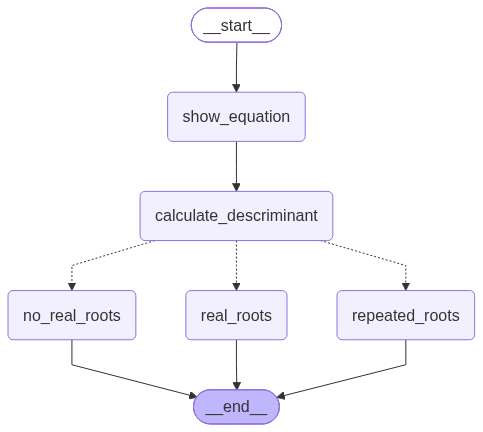

In [77]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())